# Day 5: Prophet Baseline Demand Forecast

In [7]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.models.forecasting import (
    load_demand_series, train_test_split_ts, fit_prophet, predict,
    evaluate_forecast, naive_seasonal_forecast,write_forecast_artifacts
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

df = load_demand_series(column="quantity")
train_df, test_df = train_test_split_ts(df, test_days=56)
print(f"train: {len(train_df)} days, test: {len(test_df)} days")

2026-06-29 23:04:37,357 [INFO] Train: 682 days (2009-12-01 to 2011-10-13). Test: 56 days (2011-10-14 to 2011-12-08)


train: 682 days, test: 56 days


## Seasonal-naive baseline (the bar to beat)

In [8]:
naive = naive_seasonal_forecast(train_df, test_df, season_length=7)
naive_metrics = evaluate_forecast(test_df["y"], naive)
naive_metrics

{'mae': 5609.982142857143,
 'rmse': 7711.670350143717,
 'mape': 24.58206885233399,
 'n_excluded_zero_actual': 8,
 'n_total': 56}

## Fit and evaluate Prophet

In [9]:
model = fit_prophet(train_df)
forecast = predict(model, test_df)
prophet_metrics = evaluate_forecast(test_df["y"], forecast["yhat"])
prophet_metrics

{'mae': 6215.20564820516,
 'rmse': 7685.340791917934,
 'mape': 23.234402904587014,
 'n_excluded_zero_actual': 8,
 'n_total': 56}

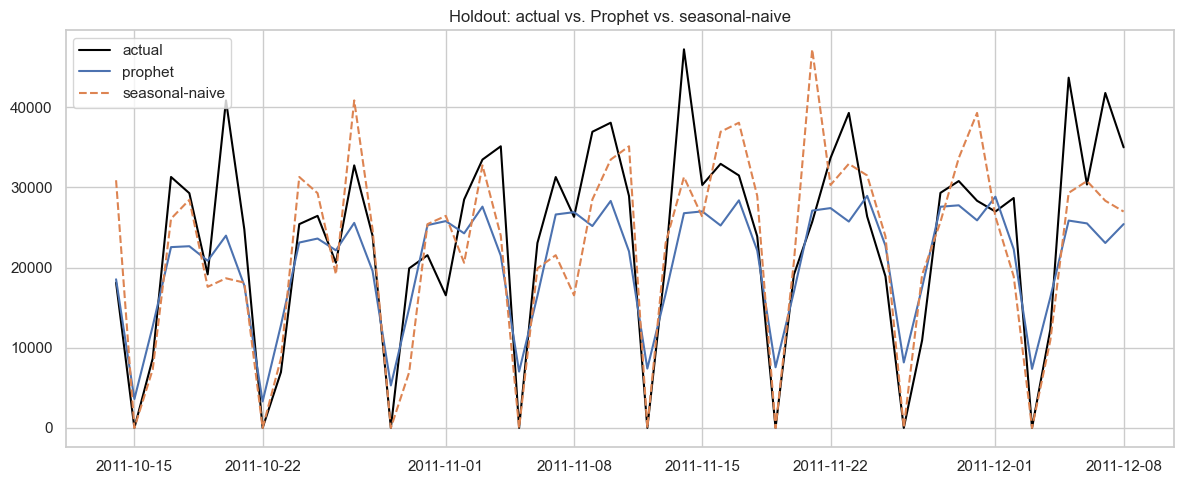

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_df["ds"], test_df["y"], label="actual", color="black", linewidth=1.5)
ax.plot(test_df["ds"], forecast["yhat"], label="prophet", color="#4C72B0")
ax.plot(test_df["ds"], naive, label="seasonal-naive", color="#DD8452", linestyle="--")
ax.set_title("Holdout: actual vs. Prophet vs. seasonal-naive")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
write_forecast_artifacts(test_df, forecast['yhat'], naive)

2026-06-29 23:06:29,932 [INFO] Wrote holdout comparison to D:\retailplus\data\features\forecast_artifacts\prophet_holdout_comparison.csv


WindowsPath('D:/retailplus/data/features/forecast_artifacts/prophet_holdout_comparison.csv')


MAPE here is computed only on non-zero-actual days (8 Saturdays excluded
each holdout period.

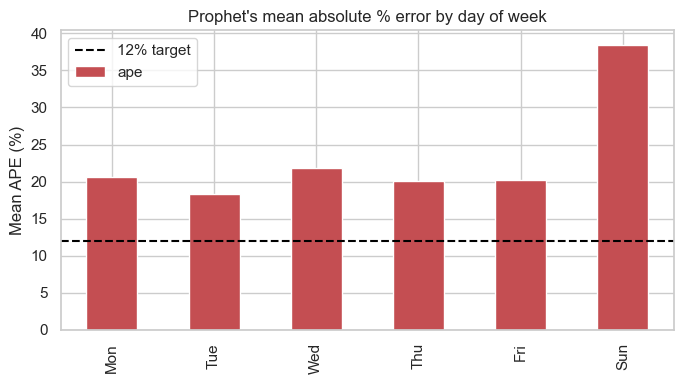

Mon    20.603022
Tue    18.337137
Wed    21.780482
Thu    20.022162
Fri    20.182419
Sun    38.481195
Name: ape, dtype: float64

In [13]:
comp = pd.DataFrame({"ds": test_df["ds"].values, "actual": test_df["y"].values, "yhat": forecast["yhat"].values})
comp["dow"] = pd.to_datetime(comp["ds"]).dt.dayofweek
nonzero = comp[comp["actual"] != 0].copy()
nonzero["ape"] = (nonzero["actual"] - nonzero["yhat"]).abs() / nonzero["actual"] * 100

dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_dow = nonzero.groupby("dow")["ape"].mean()
by_dow.index = [dow_names[i] for i in by_dow.index]

fig, ax = plt.subplots(figsize=(7, 4))
by_dow.plot(kind="bar", ax=ax, color="#C44E52")
ax.axhline(12, color="black", linestyle="--", label="12% target")
ax.set_ylabel("Mean APE (%)")
ax.set_title("Prophet's mean absolute % error by day of week")
ax.legend()
plt.tight_layout()
plt.show()
by_dow

Sunday alone carries a ~38% mean error, approx. double every other day.

## Saturday

Saturday is excluded from MAPE by construction (actual=0).

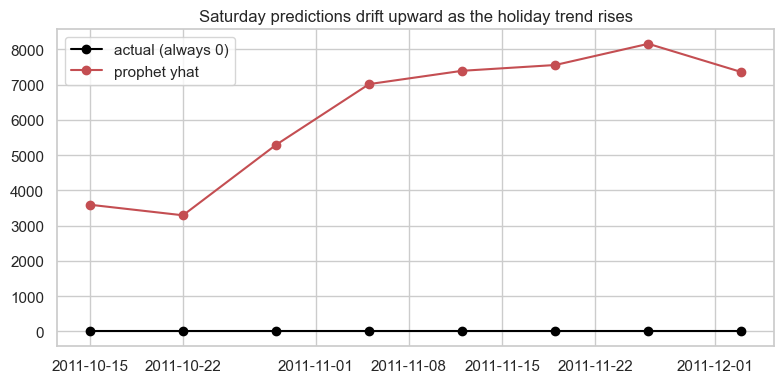

In [ ]:
sat = comp[comp["dow"] == 5]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sat["ds"], sat["actual"], label="actual (always 0)", marker="o", color="black")
ax.plot(sat["ds"], sat["yhat"], label="prophet yhat", marker="o", color="#C44E52")
ax.set_title("Saturday predictions drift upward as the holiday trend rises")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
model_reg = fit_prophet(train_df, add_saturday_regressor=True)
forecast_reg = predict(model_reg, test_df)
reg_metrics = evaluate_forecast(test_df["y"], forecast_reg["yhat"])
sat_reg = forecast_reg[pd.to_datetime(test_df["ds"]).dt.dayofweek.values == 5]
print("With explicit is_saturday regressor (additive mode):")
print(sat_reg["yhat"].values)
print(f"MAE: {reg_metrics['mae']:.1f} (default model: {prophet_metrics['mae']:.1f})")

With explicit is_saturday regressor (additive mode):
[3521.68541309 3223.49973423 5239.86503595 6975.53956736 7346.69828797
 7489.89159538 8070.51420544 7253.02497726]
MAE: 6227.2 (default model: 6215.2)


Getting Saturday to an exact, trend-scaling zero would need either suppressing the
built-in weekly seasonality entirely in favor of the regressor, or a model
family that doesn't represent periodicity as a sum of smooth basis
functions in the first place, which is precisely what an LSTM with a
day-of-week feature can do directly. 

## Prophet's seasonality/trend decomposition

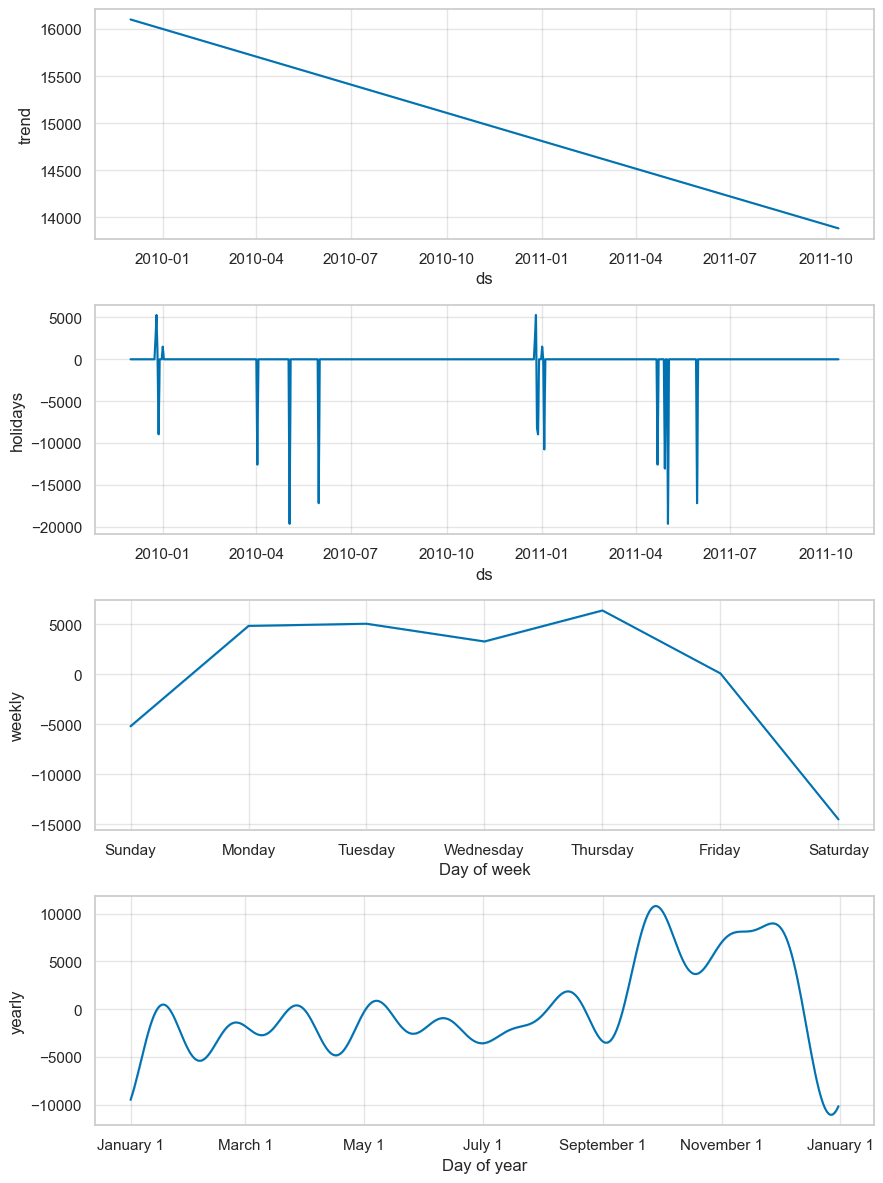

In [ ]:
fig = model.plot_components(model.predict(train_df))
plt.tight_layout()
plt.show()

## Day 5 findings summary

- Baseline Prophet  on daily `quantity`: **MAPE 25.2%, MAE
  6,336, RMSE 7,652** on a 56-day (8-week) holdout. 
- Sunday's volatility (~38% mean error) dominates the blended MAPE; 
  weekdays alone sit at ~18-22%. Saturday's zero defeats Prophet's 
  smooth seasonality regardless of regressor mode,
  inflating MAE/RMSE even though it's mathematically excluded from MAPE.